Dataset loaded successfully.
Dataset shape: (23486, 11)

First 5 rows:


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB

Missing values:
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text  

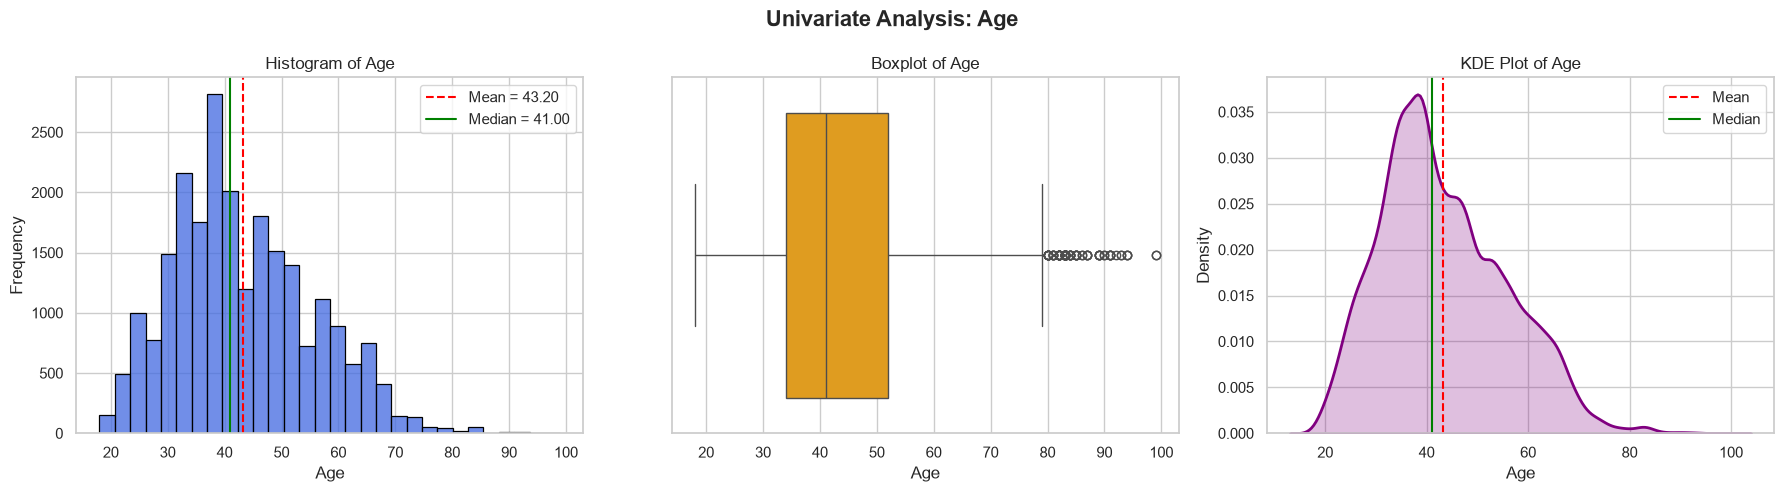

COLUMN: Age
Valid observations      : 23486
Missing values          : 0
Unique values           : 77
Mean                    : 43.20
Median                  : 41.00
Standard deviation      : 12.28
Minimum                 : 18.00
Maximum                 : 99.00
Skewness                : 0.5256
Kurtosis                : -0.1118
Potential outliers      : 109
Outlier percentage      : 0.46%
Distribution            : Moderately positively skewed
Kurtosis interpretation : Approximately mesokurtic/normal tails
Suggested action        : Mild right skew: sqrt transformation optional



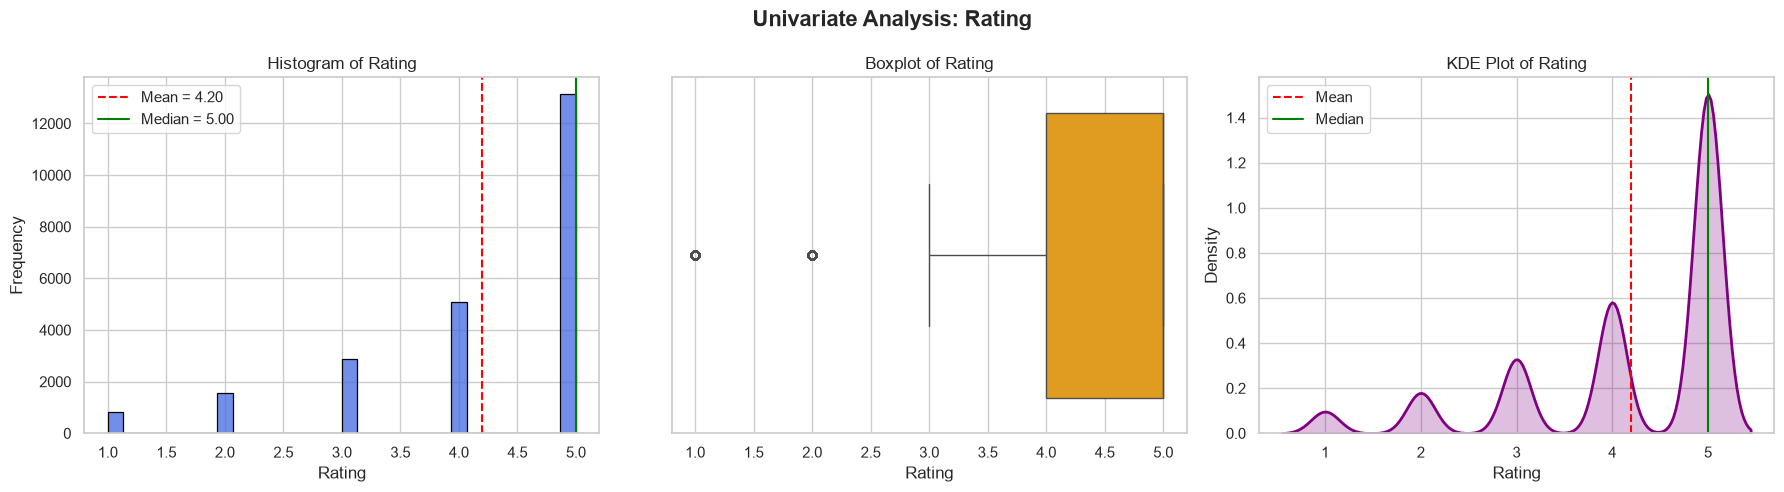

COLUMN: Rating
Valid observations      : 23486
Missing values          : 0
Unique values           : 5
Mean                    : 4.20
Median                  : 5.00
Standard deviation      : 1.11
Minimum                 : 1.00
Maximum                 : 5.00
Skewness                : -1.3135
Kurtosis                : 0.8041
Potential outliers      : 2407
Outlier percentage      : 10.25%
Distribution            : Highly negatively skewed
Kurtosis interpretation : Approximately mesokurtic/normal tails
Suggested action        : No transformation: discrete/ordinal column



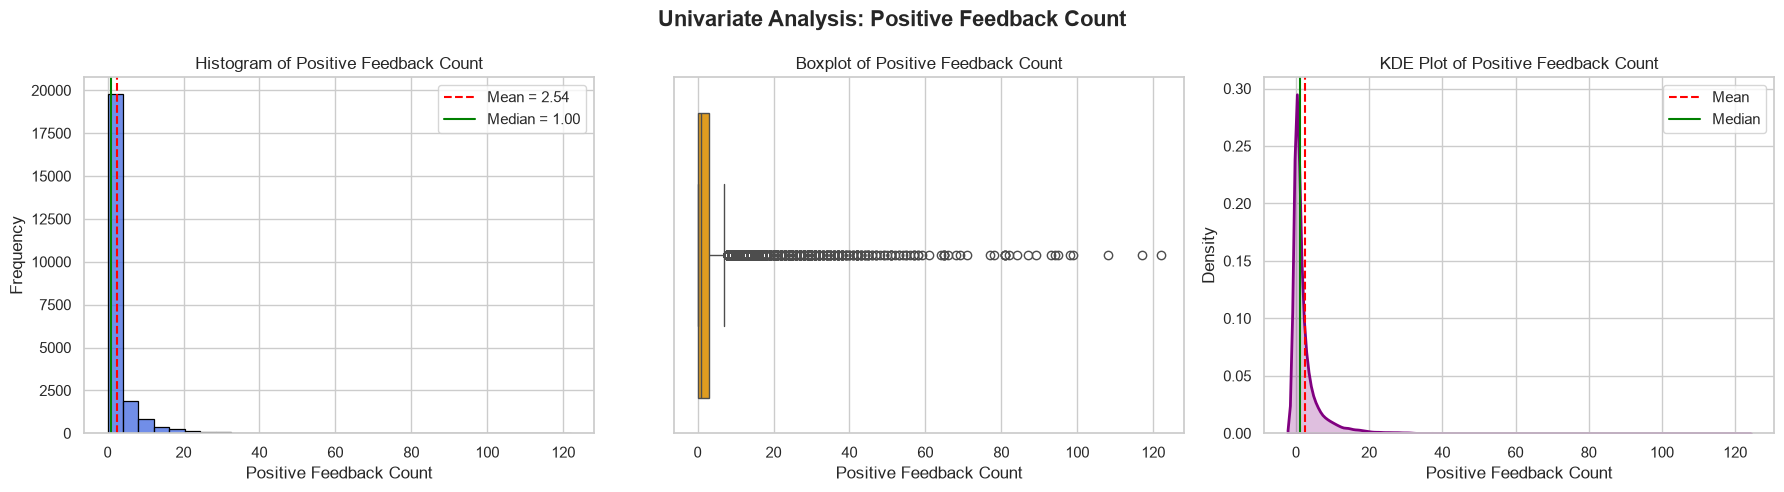

COLUMN: Positive Feedback Count
Valid observations      : 23486
Missing values          : 0
Unique values           : 82
Mean                    : 2.54
Median                  : 1.00
Standard deviation      : 5.70
Minimum                 : 0.00
Maximum                 : 122.00
Skewness                : 6.4730
Kurtosis                : 71.6932
Potential outliers      : 2147
Outlier percentage      : 9.14%
Distribution            : Highly positively skewed
Kurtosis interpretation : Leptokurtic: heavy tails/extreme values
Suggested action        : Strong right skew: apply log1p transformation


FINAL UNIVARIATE ANALYSIS SUMMARY


,Column,Count,Missing Values,Unique Values,Mean,Median,Standard Deviation,Minimum,Maximum,Skewness,Kurtosis,Outlier Count,Outlier Percentage,Distribution,Kurtosis Interpretation,Recommended Transformation
0,Age,23486,0,77,43.1985,41.0,12.2795,18,99,0.5256,-0.1118,109,0.46,Moderately positively skewed,Approximately mesokurtic/normal tails,Mild right skew: sqrt transformation optional
1,Rating,23486,0,5,4.1960,5.0,1.1100,1,5,-1.3135,0.8041,2407,10.25,Highly negatively skewed,Approximately mesokurtic/normal tails,No transformation: discrete/ordinal column
2,Positive Feedback Count,23486,0,82,2.5359,1.0,5.7022,0,122,6.4730,71.6932,2147,9.14,Highly positively skewed,Leptokurtic: heavy tails/extreme values,Strong right skew: apply log1p transformation


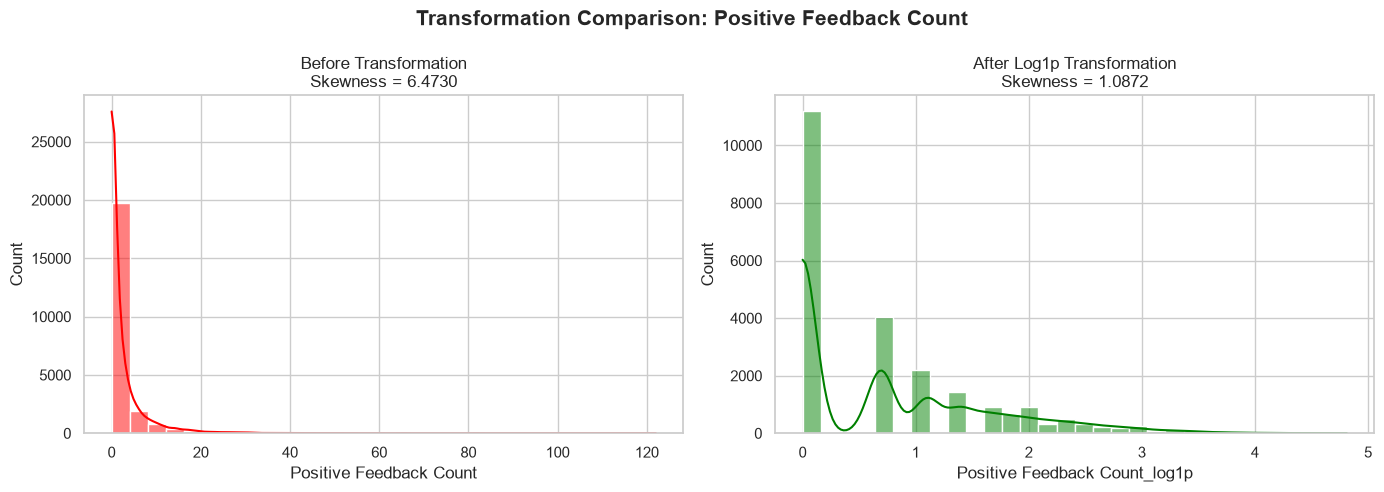


TRANSFORMATION COMPARISON


,Original Column,Transformation,Original Skewness,Transformed Skewness
0,Positive Feedback Count,Log1p,6.473,1.0872



Files saved successfully:
1. univariate_analysis_summary.csv
2. womens_clothing_univariate_processed.csv
3. transformation_comparison.csv

UNIVARIATE ANALYSIS COMPLETED SUCCESSFULLY.


In [2]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 5)

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nAll columns:")
print(df.columns.tolist())

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
    print("\n'Unnamed: 0' column removed.")

all_numerical_columns = df.select_dtypes(
    include=["number"]
).columns.tolist()

print("\nAutomatically detected numerical columns:")
print(all_numerical_columns)

analysis_columns = []

for column in all_numerical_columns:

    column_lower = column.lower()

    is_identifier = (
        "id" in column_lower or
        "index" in column_lower
    )

    is_binary = df[column].dropna().nunique() == 2

    if not is_identifier and not is_binary:
        analysis_columns.append(column)

print("\nNumerical columns selected for univariate analysis:")
print(analysis_columns)

def interpret_skewness(skew_value):

    if skew_value < -1:
        return "Highly negatively skewed"

    elif -1 <= skew_value < -0.5:
        return "Moderately negatively skewed"

    elif -0.5 <= skew_value <= 0.5:
        return "Approximately symmetric"

    elif 0.5 < skew_value <= 1:
        return "Moderately positively skewed"

    else:
        return "Highly positively skewed"

def interpret_kurtosis(kurtosis_value):

    if kurtosis_value > 1:
        return "Leptokurtic: heavy tails/extreme values"

    elif kurtosis_value < -1:
        return "Platykurtic: flat distribution"

    else:
        return "Approximately mesokurtic/normal tails"

def recommend_transformation(series, skew_value):

    unique_values = series.nunique()
    minimum_value = series.min()

    if unique_values <= 10:
        return "No transformation: discrete/ordinal column"

    if abs(skew_value) <= 0.5:
        return "No transformation required"

    elif 0.5 < skew_value <= 1:
        return "Mild right skew: sqrt transformation optional"

    elif skew_value > 1 and minimum_value >= 0:
        return "Strong right skew: apply log1p transformation"

    elif skew_value < -1:
        return "Strong left skew: consider Yeo-Johnson transformation"

    else:
        return "Consider Yeo-Johnson transformation"

def univariate_analysis(data, column):

    series = data[column].dropna()

    count = series.count()
    missing = data[column].isnull().sum()
    unique_values = series.nunique()

    mean_value = series.mean()
    median_value = series.median()
    std_value = series.std()

    minimum_value = series.min()
    maximum_value = series.max()

    skew_value = series.skew()
    kurtosis_value = series.kurtosis()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - (1.5 * iqr)
    upper_limit = q3 + (1.5 * iqr)

    outlier_mask = (
        (series < lower_limit) |
        (series > upper_limit)
    )

    outlier_count = outlier_mask.sum()
    outlier_percentage = (outlier_count / count) * 100

    skew_interpretation = interpret_skewness(skew_value)
    kurtosis_interpretation = interpret_kurtosis(kurtosis_value)

    transformation = recommend_transformation(
        series,
        skew_value
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(
        data=series,
        bins=30,
        color="royalblue",
        edgecolor="black",
        ax=axes[0]
    )

    axes[0].axvline(
        mean_value,
        color="red",
        linestyle="--",
        label=f"Mean = {mean_value:.2f}"
    )

    axes[0].axvline(
        median_value,
        color="green",
        linestyle="-",
        label=f"Median = {median_value:.2f}"
    )

    axes[0].set_title(f"Histogram of {column}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Frequency")
    axes[0].legend()

    sns.boxplot(
        x=series,
        color="orange",
        ax=axes[1]
    )

    axes[1].set_title(f"Boxplot of {column}")
    axes[1].set_xlabel(column)

    if unique_values > 1:
        sns.kdeplot(
            x=series,
            fill=True,
            color="purple",
            linewidth=2,
            ax=axes[2]
        )

    axes[2].axvline(
        mean_value,
        color="red",
        linestyle="--",
        label="Mean"
    )

    axes[2].axvline(
        median_value,
        color="green",
        linestyle="-",
        label="Median"
    )

    axes[2].set_title(f"KDE Plot of {column}")
    axes[2].set_xlabel(column)
    axes[2].set_ylabel("Density")
    axes[2].legend()

    plt.suptitle(
        f"Univariate Analysis: {column}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    print("=" * 70)
    print("COLUMN:", column)
    print("=" * 70)

    print(f"Valid observations      : {count}")
    print(f"Missing values          : {missing}")
    print(f"Unique values           : {unique_values}")
    print(f"Mean                    : {mean_value:.2f}")
    print(f"Median                  : {median_value:.2f}")
    print(f"Standard deviation      : {std_value:.2f}")
    print(f"Minimum                 : {minimum_value:.2f}")
    print(f"Maximum                 : {maximum_value:.2f}")
    print(f"Skewness                : {skew_value:.4f}")
    print(f"Kurtosis                : {kurtosis_value:.4f}")
    print(f"Potential outliers      : {outlier_count}")
    print(f"Outlier percentage      : {outlier_percentage:.2f}%")
    print(f"Distribution            : {skew_interpretation}")
    print(f"Kurtosis interpretation : {kurtosis_interpretation}")
    print(f"Suggested action        : {transformation}")
    print()

    return {
        "Column": column,
        "Count": count,
        "Missing Values": missing,
        "Unique Values": unique_values,
        "Mean": round(mean_value, 4),
        "Median": round(median_value, 4),
        "Standard Deviation": round(std_value, 4),
        "Minimum": minimum_value,
        "Maximum": maximum_value,
        "Skewness": round(skew_value, 4),
        "Kurtosis": round(kurtosis_value, 4),
        "Outlier Count": outlier_count,
        "Outlier Percentage": round(outlier_percentage, 2),
        "Distribution": skew_interpretation,
        "Kurtosis Interpretation": kurtosis_interpretation,
        "Recommended Transformation": transformation
    }

analysis_results = []

for column in analysis_columns:

    result = univariate_analysis(
        data=df,
        column=column
    )

    analysis_results.append(result)

summary_df = pd.DataFrame(analysis_results)

print("\nFINAL UNIVARIATE ANALYSIS SUMMARY")
display(summary_df)

df_transformed = df.copy()

transformation_results = []

for column in analysis_columns:

    original_series = df[column].dropna()
    original_skewness = original_series.skew()

    if (
        original_skewness > 1 and
        original_series.min() >= 0 and
        original_series.nunique() > 10
    ):

        transformed_column = column + "_log1p"

        df_transformed[transformed_column] = np.log1p(
            df_transformed[column]
        )

        transformed_skewness = (
            df_transformed[transformed_column]
            .dropna()
            .skew()
        )

        transformation_results.append({
            "Original Column": column,
            "Transformation": "Log1p",
            "Original Skewness": round(original_skewness, 4),
            "Transformed Skewness": round(
                transformed_skewness,
                4
            )
        })

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.histplot(
            df[column].dropna(),
            bins=30,
            kde=True,
            color="red",
            ax=axes[0]
        )

        axes[0].set_title(
            f"Before Transformation\n"
            f"Skewness = {original_skewness:.4f}"
        )

        sns.histplot(
            df_transformed[transformed_column].dropna(),
            bins=30,
            kde=True,
            color="green",
            ax=axes[1]
        )

        axes[1].set_title(
            f"After Log1p Transformation\n"
            f"Skewness = {transformed_skewness:.4f}"
        )

        plt.suptitle(
            f"Transformation Comparison: {column}",
            fontsize=15,
            fontweight="bold"
        )

        plt.tight_layout()
        plt.show()

transformation_summary_df = pd.DataFrame(
    transformation_results
)

if len(transformation_summary_df) > 0:

    print("\nTRANSFORMATION COMPARISON")
    display(transformation_summary_df)

else:
    print("\nNo strong transformation was required.")

summary_df.to_csv(
    "univariate_analysis_summary.csv",
    index=False
)

df_transformed.to_csv(
    "womens_clothing_univariate_processed.csv",
    index=False
)

if len(transformation_summary_df) > 0:
    transformation_summary_df.to_csv(
        "transformation_comparison.csv",
        index=False
    )

print("\nFiles saved successfully:")
print("1. univariate_analysis_summary.csv")
print("2. womens_clothing_univariate_processed.csv")

if len(transformation_summary_df) > 0:
    print("3. transformation_comparison.csv")

print("\nUNIVARIATE ANALYSIS COMPLETED SUCCESSFULLY.")